In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing ins

In [2]:
yaml_path = '/kaggle/input/floatingdata/yolo_dataset/data.yaml'

In [3]:
import os
import glob
from collections import defaultdict

# Directory containing the annotation files (labels)
annotation_dir = '/kaggle/input/floatingdata/yolo_dataset/train/labels'

# List of classes in your dataset
class_names = ['carton', 'bottle', 'paper', 'plastic']  # Update with your classes

# Create a dictionary to store count of images per class
class_count = defaultdict(int)

# Iterate over each annotation file (e.g., text files) in the annotation folder
for annotation_file in glob.glob(os.path.join(annotation_dir, '*.txt')):
    # Read the annotation file and count the classes
    with open(annotation_file, 'r') as file:
        lines = file.readlines()
        for line in lines:
            class_id = int(line.split()[0])  # The first value in each line is the class index
            class_count[class_id] += 1

# Print out the count for each class
for class_id, count in class_count.items():
    print(f"Class {class_names[class_id]} ({class_id}): {count} images")


Class plastic (3): 482 images
Class carton (0): 1056 images
Class bottle (1): 2550 images
Class paper (2): 427 images


In [4]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# Load YOLOv8n model
model = YOLO('yolov8n.pt')

# Check model architecture
model.info()

100%|██████████| 6.25M/6.25M [00:00<00:00, 282MB/s]


YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [6]:
model.train(
    data='/kaggle/input/floatingdata/yolo_dataset/data.yaml',  # Path to the data.yaml file
    epochs=50,  # Number of epochs
    imgsz=640,  # Image size
    batch=16,  # Batch size
    project='/kaggle/working/Floatingwaste_model',  # Save results in the same directory
    name='Floatingwasten_yolov8',  # Name of the experiment
    device=0,  # Use GPU
    save_period=1
)

Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/input/floatingdata/yolo_dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=1, cache=False, device=0, workers=8, project=/kaggle/working/Floatingwaste_model, name=Floatingwasten_yolov8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, s

100%|██████████| 755k/755k [00:00<00:00, 93.7MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 313MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 64.9±12.7 MB/s, size: 640.1 KB)


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  3.40it/s]


                   all        164        553      0.794      0.669      0.737       0.38
                carton         75        136      0.775      0.721      0.767       0.38
                bottle        135        318      0.872      0.664      0.772      0.375
                 paper         35         43      0.682      0.558      0.624      0.297
               plastic         44         56      0.849      0.732      0.786      0.468


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /kaggle/working/Floatingwaste_model/Floatingwasten_yolov8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78728b2cae50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [7]:
results = model.val()

Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 469.6±108.3 MB/s, size: 576.6 KB)


val: Scanning /kaggle/input/floatingdata/yolo_dataset/val/labels... 164 images, 0 backgrounds, 0 corrupt: 100%|██████████| 164/164 [00:00<00:00, 538.30it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/floatingdata/yolo_dataset/val is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:02<00:00,  4.03it/s]


                   all        164        553      0.796      0.664      0.738      0.384
                carton         75        136      0.791      0.724      0.779      0.382
                bottle        135        318      0.875      0.664      0.772      0.375
                 paper         35         43      0.665      0.535       0.62      0.308
               plastic         44         56      0.854      0.732       0.78       0.47


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.1ms preprocess, 2.5ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/Floatingwaste_model/Floatingwasten_yolov82


In [8]:
model = YOLO('/kaggle/working/Floatingwaste_model/Floatingwasten_yolov8/weights/best.pt')

In [10]:
results = model.val(
    data='/kaggle/input/floatingdata/yolo_dataset/data.yaml',  # Path to your YAML file
    split='test',  # Specify that you want to evaluate on the test set
    imgsz=640,  # Image size
    batch=16,  # Batch size
    project='/kaggle/working/Floatingwaste_model',
    name='test_evaluation'
)

Ultralytics 8.3.121 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 40.1±17.5 MB/s, size: 488.5 KB)


val: Scanning /kaggle/input/floatingdata/yolo_dataset/test/labels... 164 images, 0 backgrounds, 0 corrupt: 100%|██████████| 164/164 [00:01<00:00, 152.54it/s]

WARNING ⚠️ val: Cache directory /kaggle/input/floatingdata/yolo_dataset/test is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:02<00:00,  4.73it/s]


                   all        164        568      0.825      0.632      0.704      0.341
                carton         75        110      0.866      0.645      0.759      0.386
                bottle        138        345      0.844      0.591      0.707      0.319
                 paper         32         48      0.728      0.521      0.512      0.214
               plastic         50         65      0.862      0.771      0.837      0.446


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.2ms preprocess, 1.5ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /kaggle/working/Floatingwaste_model/test_evaluation2



image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1019.jpg: 384x640 1 carton, 3 bottles, 34.5ms
Speed: 2.1ms preprocess, 34.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


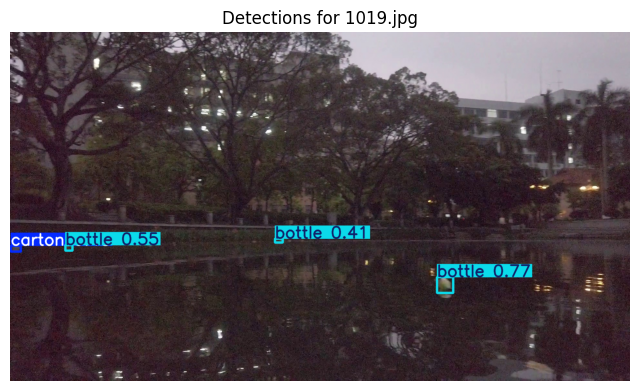


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1029.jpg: 384x640 1 carton, 2 bottles, 1 plastic, 6.9ms
Speed: 2.7ms preprocess, 6.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


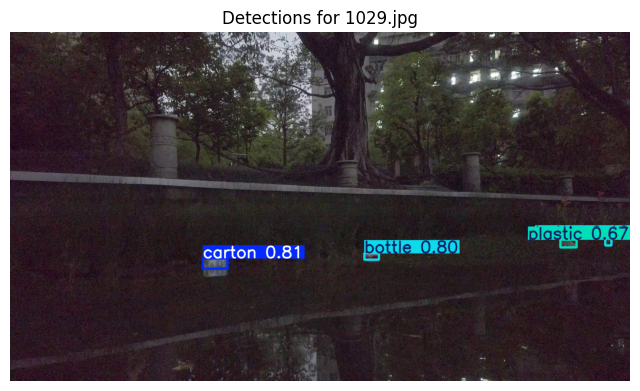


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1041.jpg: 384x640 2 bottles, 6.9ms
Speed: 2.1ms preprocess, 6.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


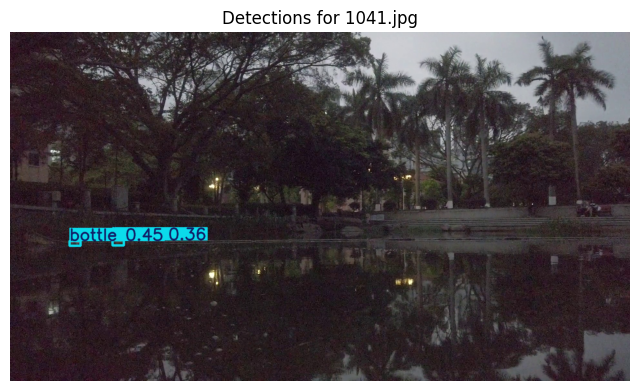


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1042.jpg: 384x640 2 bottles, 6.9ms
Speed: 2.3ms preprocess, 6.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


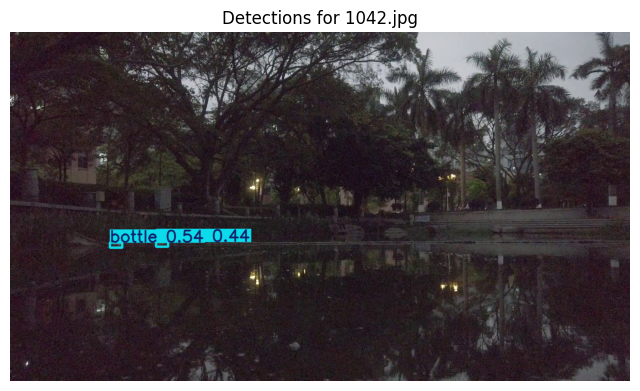


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1059.jpg: 384x640 1 bottle, 7.0ms
Speed: 2.4ms preprocess, 7.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


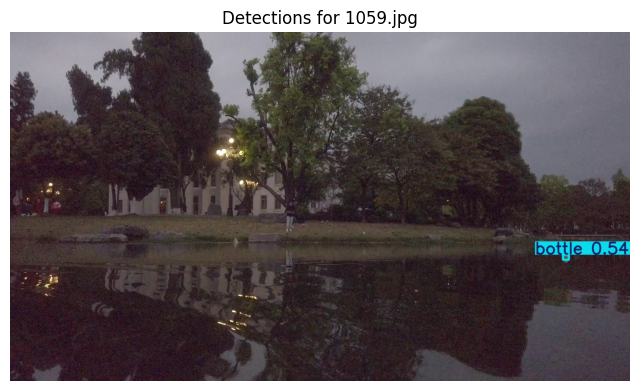


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1095.jpg: 384x640 1 bottle, 1 paper, 7.1ms
Speed: 2.5ms preprocess, 7.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


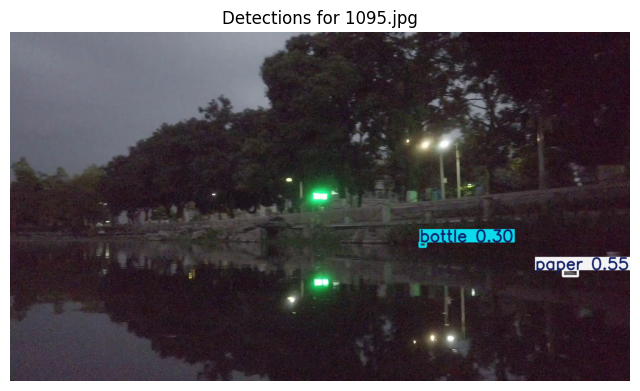


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1097.jpg: 384x640 1 carton, 6.9ms
Speed: 2.1ms preprocess, 6.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


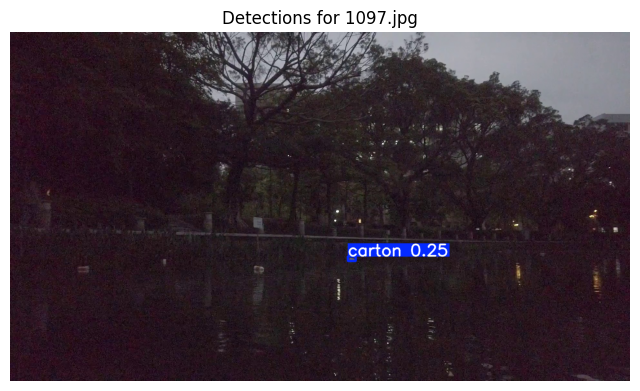


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/112.jpg: 384x640 1 carton, 6.8ms
Speed: 2.2ms preprocess, 6.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


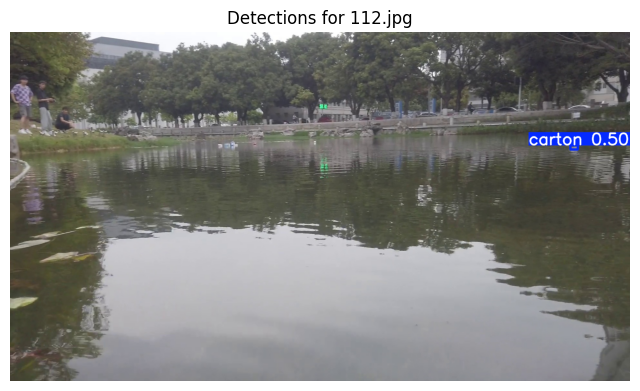


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1139.jpg: 384x640 1 carton, 5 bottles, 6.8ms
Speed: 2.1ms preprocess, 6.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


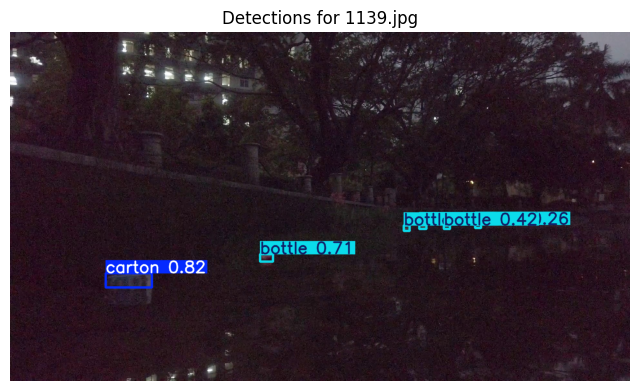


image 1/1 /kaggle/input/floatingdata/yolo_dataset/test/images/1201.jpg: 384x640 1 bottle, 6.8ms
Speed: 2.1ms preprocess, 6.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


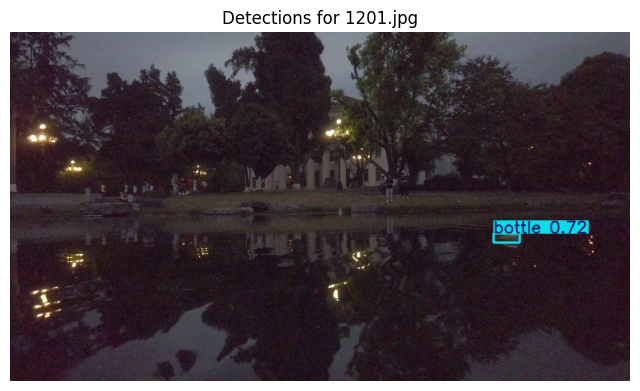

In [11]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load your trained model
model = YOLO('/kaggle/working/Floatingwaste_model/Floatingwasten_yolov8/weights/best.pt')

# Path to test images
test_images_path = '/kaggle/input/floatingdata/yolo_dataset/test/images'
image_files = sorted(os.listdir(test_images_path))[:10]  # First 10 images

# Run detection and plot
for img_file in image_files:
    img_path = os.path.join(test_images_path, img_file)

    # Run prediction
    results = model.predict(source=img_path, save=False, imgsz=640, conf=0.25)

    # Get rendered image with boxes
    result_img = results[0].plot()

    # Convert BGR to RGB for matplotlib
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    # Show image
    plt.figure(figsize=(8, 6))
    plt.imshow(result_img)
    plt.title(f'Detections for {img_file}')
    plt.axis('off')
    plt.show()
